<a href="https://colab.research.google.com/github/aryanranga721-ops/Celebal_Internship/blob/main/Week5_Aryan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

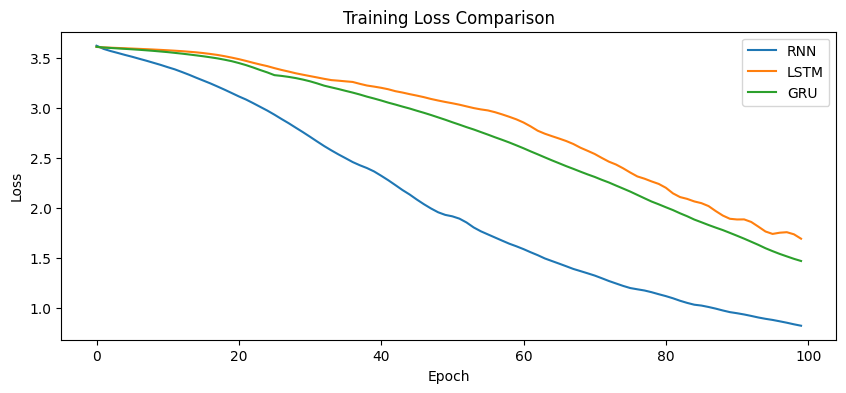

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is transforming artificial intelligence sentences
LSTM: deep learning models models generate meaningful sentences
GRU : deep learning models predict the next word


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

---
#**1. Replace corpus with Shakespeare text**

In [10]:
corpus2 = '''
to be or not to be that is the question
whether tis nobler in the mind to suffer
the slings and arrows of outrageous fortune
'''
print(corpus2)


to be or not to be that is the question
whether tis nobler in the mind to suffer
the slings and arrows of outrageous fortune



## 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [11]:
tokenizer2 = Tokenizer()
tokenizer2.fit_on_texts([corpus2])

total_words2= len(tokenizer2.word_index) + 1
print("Vocabulary size:", total_words2)

input_sequences2 = []
for line in corpus2.split('\n'):
    token_list2 = tokenizer2.texts_to_sequences([line])[0]
    for i in range(1, len(token_list2)):
        n_gram_seq = token_list2[:i+1]
        input_sequences2.append(n_gram_seq)

max_len2 = max(len(seq) for seq in input_sequences2)
input_sequences2 = pad_sequences(input_sequences2, maxlen=max_len2, padding='pre')

X2 = input_sequences2[:, :-1]
y2 = input_sequences2[:, -1]

print("X shape:", X2.shape)
print("y shape:", y2.shape)

Vocabulary size: 21
X shape: (22, 9)
y shape: (22,)


## 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.
- Increase embedding dimension
- Increase epochs to 200
- Change hidden units 64 → 128

In [12]:
rnn_model2 = Sequential([
    Embedding(total_words2, 64, input_length=max_len2-1),
    SimpleRNN(128),
    Dense(total_words2, activation='softmax')
])

rnn_model2.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history2 = rnn_model2.fit(X2, y2, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


## 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.
- Increase embedding dimension

- Increase epochs to 200

- Change hidden units 64 → 128

In [13]:
lstm_model2 = Sequential([
    Embedding(total_words2, 64, input_length=max_len2-1),
    LSTM(128),
    Dense(total_words2, activation='softmax')
])

lstm_model2.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history2 = lstm_model2.fit(X2, y2, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


## ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.
- Increase embedding dimension

- Increase epochs to 200

- Change hidden units 64 → 128

In [14]:
gru_model2 = Sequential([
    Embedding(total_words2, 64, input_length=max_len2-1),
    GRU(128),
    Dense(total_words2, activation='softmax')
])

gru_model2.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history2 = gru_model2.fit(X2, y2, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

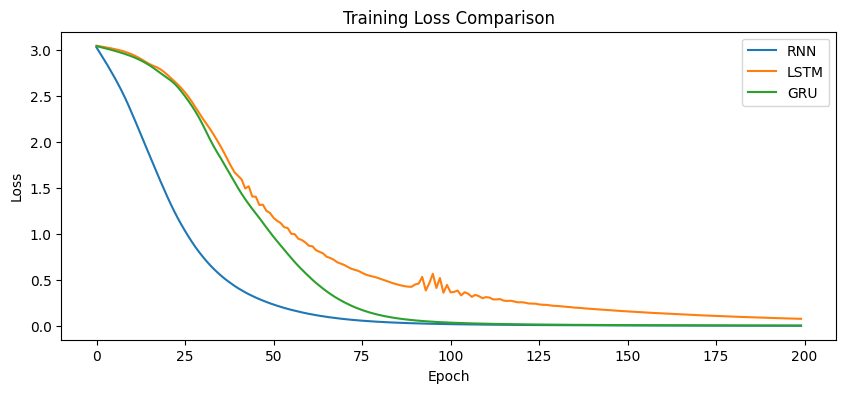

In [15]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history2.history['loss'], label='RNN')
plt.plot(lstm_history2.history['loss'], label='LSTM')
plt.plot(gru_history2.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

## ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [16]:
def generate_text2(model2, seed_text2, next_words2=5):
    for _ in range(next_words2):
        token_list2 = tokenizer2.texts_to_sequences([seed_text2])[0]
        token_list2 = pad_sequences([token_list2], maxlen=max_len-1, padding='pre')
        predicted2 = np.argmax(model2.predict(token_list2, verbose=0), axis=-1)[0]

        output_word2 = ""
        for word2, index2 in tokenizer2.word_index.items():
            if index2 == predicted2:
                output_word2 = word2
                break
        seed_text2 += " " + output_word2
    return seed_text2

## 🧪 Generate Text Samples

In [17]:
print("RNN :", generate_text2(rnn_model2, "to be", 10))
print("LSTM:", generate_text2(lstm_model2, "to be", 10))
print("GRU :", generate_text2(gru_model2, "to be", 10))

RNN : to be or not to be that is the question that is
LSTM: to be not to be that is question question question question question
GRU : to be or not to be that the question question question question


---
#**2.Replace corpus with song lyrics.**

In [18]:
corpus3 = '''
here comes the sun and i say
its all right little darling
the smiles returning to the faces
'''
print(corpus3)


here comes the sun and i say
its all right little darling
the smiles returning to the faces



## 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [19]:
tokenizer3 = Tokenizer()
tokenizer3.fit_on_texts([corpus3])

total_words3= len(tokenizer3.word_index) + 1
print("Vocabulary size:", total_words3)

input_sequences3 = []
for line in corpus3.split('\n'):
    token_list3 = tokenizer3.texts_to_sequences([line])[0]
    for i in range(1, len(token_list3)):
        n_gram_seq = token_list3[:i+1]
        input_sequences3.append(n_gram_seq)

max_len3 = max(len(seq) for seq in input_sequences3)
input_sequences3 = pad_sequences(input_sequences3, maxlen=max_len3, padding='pre')

X3 = input_sequences3[:, :-1]
y3 = input_sequences3[:, -1]

print("X shape:", X3.shape)
print("y shape:", y3.shape)

Vocabulary size: 17
X shape: (15, 6)
y shape: (15,)


## 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.
- Increase embedding dimension
- Increase epochs to 300
- Change hidden units 64 → 128

In [20]:
rnn_model3 = Sequential([
    Embedding(total_words3, 64, input_length=max_len3-1),
    SimpleRNN(128),
    Dense(total_words3, activation='softmax')
])

rnn_model3.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history3 = rnn_model3.fit(X3, y3, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


## 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.
- Increase embedding dimension

- Increase epochs to 200

- Change hidden units 64 → 128

In [21]:
lstm_model3 = Sequential([
    Embedding(total_words3, 64, input_length=max_len3-1),
    LSTM(128),
    Dense(total_words3, activation='softmax')
])

lstm_model3.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history3 = lstm_model3.fit(X3, y3, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


## ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.
- Increase embedding dimension

- Increase epochs to 200

- Change hidden units 64 → 128

In [22]:
gru_model3 = Sequential([
    Embedding(total_words3, 64, input_length=max_len3-1),
    GRU(128),
    Dense(total_words3, activation='softmax')
])

gru_model3.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history3 = gru_model3.fit(X3, y3, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

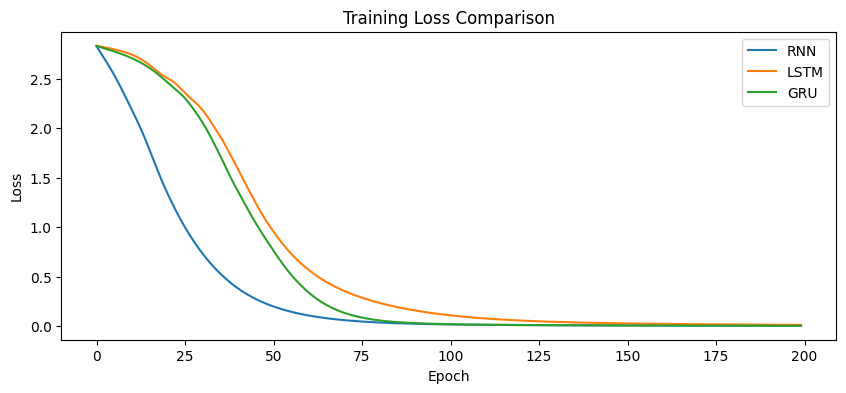

In [23]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history3.history['loss'], label='RNN')
plt.plot(lstm_history3.history['loss'], label='LSTM')
plt.plot(gru_history3.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

## ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [24]:
def generate_text3(model3, seed_text3, next_words3=5):
    for _ in range(next_words3):
        token_list3 = tokenizer3.texts_to_sequences([seed_text3])[0]
        token_list3 = pad_sequences([token_list3], maxlen=max_len-1, padding='pre')
        predicted3 = np.argmax(model3.predict(token_list3, verbose=0), axis=-1)[0]

        output_word3 = ""
        for word3, index3 in tokenizer3.word_index.items():
            if index3 == predicted3:
                output_word3 = word3
                break
        seed_text3 += " " + output_word3
    return seed_text3

## 🧪 Generate Text Samples

In [25]:
print("RNN :", generate_text3(rnn_model3, "its all", 10))
print("LSTM:", generate_text3(lstm_model3, "its all", 10))
print("GRU :", generate_text3(gru_model3, "its all", 10))

RNN : its all right little darling faces little darling darling faces say i
LSTM: its all right little little darling darling darling say say say say
GRU : its all right little darling darling darling darling darling say say say


---
#**3. Replace corpus with chatbot data.**

In [26]:
corpus4 = '''
hello how are you
i am doing well thank you
what can you help me with
i can answer questions and provide information
'''
print(corpus4)


hello how are you
i am doing well thank you
what can you help me with
i can answer questions and provide information



## 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [27]:
tokenizer4 = Tokenizer()
tokenizer4.fit_on_texts([corpus4])

total_words4= len(tokenizer4.word_index) + 1
print("Vocabulary size:", total_words4)

input_sequences4 = []
for line in corpus4.split('\n'):
    token_list4 = tokenizer4.texts_to_sequences([line])[0]
    for i in range(1, len(token_list4)):
        n_gram_seq = token_list4[:i+1]
        input_sequences4.append(n_gram_seq)

max_len4 = max(len(seq) for seq in input_sequences4)
input_sequences4 = pad_sequences(input_sequences4, maxlen=max_len4, padding='pre')

X4 = input_sequences4[:, :-1]
y4 = input_sequences4[:, -1]

print("X shape:", X4.shape)
print("y shape:", y4.shape)

Vocabulary size: 20
X shape: (19, 6)
y shape: (19,)


## 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.
- Increase embedding dimension
- Increase epochs to 200
- Change hidden units 64 → 128

In [28]:
rnn_model4 = Sequential([
    Embedding(total_words4, 64, input_length=max_len4-1),
    SimpleRNN(128),
    Dense(total_words4, activation='softmax')
])

rnn_model4.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history4 = rnn_model4.fit(X4, y4, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


## 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.
- Increase embedding dimension

- Increase epochs to 200

- Change hidden units 64 → 128

In [29]:
lstm_model4 = Sequential([
    Embedding(total_words4, 64, input_length=max_len4-1),
    LSTM(128),
    Dense(total_words4, activation='softmax')
])

lstm_model4.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history4 = lstm_model4.fit(X4, y4, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


## ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.
- Increase embedding dimension

- Increase epochs to 200

- Change hidden units 64 → 128

In [30]:
gru_model4 = Sequential([
    Embedding(total_words4, 64, input_length=max_len4-1),
    GRU(128),
    Dense(total_words4, activation='softmax')
])

gru_model4.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history4 = gru_model4.fit(X4, y4, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

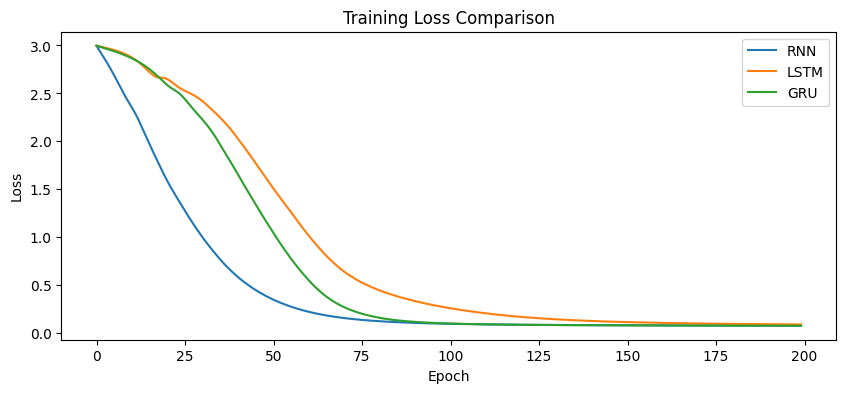

In [31]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history4.history['loss'], label='RNN')
plt.plot(lstm_history4.history['loss'], label='LSTM')
plt.plot(gru_history4.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

## ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [32]:
def generate_text4(model4, seed_text4, next_words4=5):
    for _ in range(next_words4):
        token_list4 = tokenizer4.texts_to_sequences([seed_text4])[0]
        token_list4 = pad_sequences([token_list4], maxlen=max_len-1, padding='pre')
        predicted4 = np.argmax(model4.predict(token_list4, verbose=0), axis=-1)[0]

        output_word4 = ""
        for word4, index4 in tokenizer4.word_index.items():
            if index4 == predicted4:
                output_word4 = word4
                break
        seed_text4 += " " + output_word4
    return seed_text4

## 🧪 Generate Text Samples

In [33]:
print("RNN :", generate_text4(rnn_model4, "i am", 10))
print("LSTM:", generate_text4(lstm_model4, "i am", 10))
print("GRU :", generate_text4(gru_model4, "i am", 10))

RNN : i am doing well thank you help me with information you provide
LSTM: i am doing well thank thank you you you with with with
GRU : i am doing well thank you you me with with with with


---
#**4.Replace corpus with chatbot data.**

In [34]:
corpus5 = '''
once upon a time there was a brave knight
the knight lived in a beautiful kingdom
he protected the people from danger
everyone admired his courage and kindness
'''
print(corpus5)


once upon a time there was a brave knight
the knight lived in a beautiful kingdom
he protected the people from danger
everyone admired his courage and kindness



## 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [35]:
tokenizer5 = Tokenizer()
tokenizer5.fit_on_texts([corpus5])

total_words5= len(tokenizer5.word_index) + 1
print("Vocabulary size:", total_words5)

input_sequences5 = []
for line in corpus5.split('\n'):
    token_list5 = tokenizer5.texts_to_sequences([line])[0]
    for i in range(1, len(token_list5)):
        n_gram_seq = token_list5[:i+1]
        input_sequences5.append(n_gram_seq)

max_len5 = max(len(seq) for seq in input_sequences5)
input_sequences5 = pad_sequences(input_sequences5, maxlen=max_len5, padding='pre')

X5 = input_sequences5[:, :-1]
y5 = input_sequences5[:, -1]

print("X shape:", X5.shape)
print("y shape:", y5.shape)

Vocabulary size: 25
X shape: (24, 8)
y shape: (24,)


## 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.
- Increase embedding dimension
- Increase epochs to 500
- Change hidden units 64 → 128

In [36]:
rnn_model5 = Sequential([
    Embedding(total_words5, 64, input_length=max_len5-1),
    SimpleRNN(128),
    Dense(total_words5, activation='softmax')
])

rnn_model5.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history5 = rnn_model5.fit(X5, y5, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


## 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.
- Increase embedding dimension

- Increase epochs to 200

- Change hidden units 64 → 128

In [37]:
lstm_model5 = Sequential([
    Embedding(total_words5, 64, input_length=max_len5-1),
    LSTM(128),
    Dense(total_words5, activation='softmax')
])

lstm_model5.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history5 = lstm_model5.fit(X5, y5, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


## ⚡ Model 5: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.
- Increase embedding dimension

- Increase epochs to 200

- Change hidden units 64 → 128

In [38]:
gru_model5 = Sequential([
    Embedding(total_words5, 64, input_length=max_len5-1),
    GRU(128),
    Dense(total_words5, activation='softmax')
])

gru_model5.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history5 = gru_model5.fit(X5, y5, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

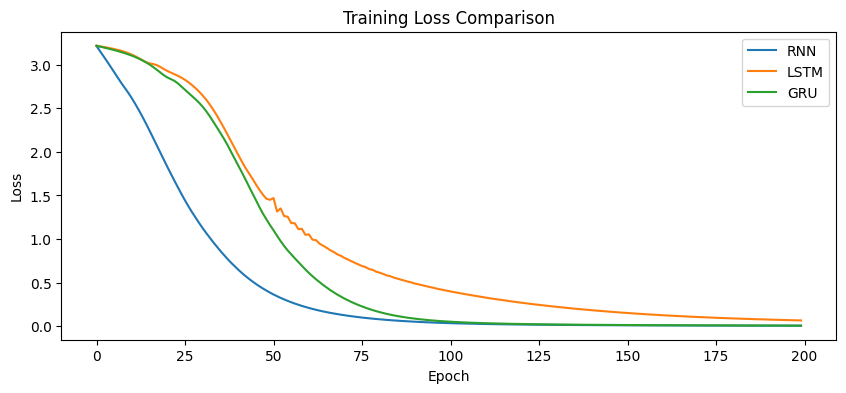

In [39]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history5.history['loss'], label='RNN')
plt.plot(lstm_history5.history['loss'], label='LSTM')
plt.plot(gru_history5.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

## ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [40]:
def generate_text5(model5, seed_text5, next_words5=5):
    for _ in range(next_words5):
        token_list5 = tokenizer5.texts_to_sequences([seed_text5])[0]
        token_list5 = pad_sequences([token_list5], maxlen=max_len-1, padding='pre')
        predicted5 = np.argmax(model5.predict(token_list5, verbose=0), axis=-1)[0]

        output_word5 = ""
        for word5, index5 in tokenizer5.word_index.items():
            if index5 == predicted5:
                output_word5 = word5
                break
        seed_text5 += " " + output_word5
    return seed_text5

## 🧪 Generate Text Samples

In [41]:
print("RNN :", generate_text5(rnn_model5, "Once upon", 10))
print("LSTM:", generate_text5(lstm_model5, "Once upon", 10))
print("GRU :", generate_text5(gru_model5, "Once upon", 10))

RNN : Once upon a time there was a brave knight lived brave was
LSTM: Once upon a time was a brave knight knight knight knight knight
GRU : Once upon a time there was a brave knight knight a time


---
#**5.Replace corpus with custom PDF extracted text.**

In [42]:
corpus6= '''
machine learning is a subset of artificial intelligence
deep learning uses neural networks with multiple layers
data quality plays an important role in model performance
'''
print(corpus6)


machine learning is a subset of artificial intelligence
deep learning uses neural networks with multiple layers
data quality plays an important role in model performance



## 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [43]:
tokenizer6 = Tokenizer()
tokenizer6.fit_on_texts([corpus6])

total_words6= len(tokenizer6.word_index) + 1
print("Vocabulary size:", total_words6)

input_sequences6 = []
for line in corpus6.split('\n'):
    token_list6 = tokenizer6.texts_to_sequences([line])[0]
    for i in range(1, len(token_list6)):
        n_gram_seq = token_list6[:i+1]
        input_sequences6.append(n_gram_seq)

max_len6 = max(len(seq) for seq in input_sequences6)
input_sequences6 = pad_sequences(input_sequences6, maxlen=max_len6, padding='pre')

X6 = input_sequences6[:, :-1]
y6 = input_sequences6[:, -1]

print("X shape:", X6.shape)
print("y shape:", y6.shape)

Vocabulary size: 25
X shape: (22, 8)
y shape: (22,)


## 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.
- Increase embedding dimension
- Increase epochs to 200
- Change hidden units 64 → 128

In [44]:
rnn_model6 = Sequential([
    Embedding(total_words6, 64, input_length=max_len6-1),
    SimpleRNN(128),
    Dense(total_words6, activation='softmax')
])

rnn_model6.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history6 = rnn_model6.fit(X6, y6, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


## 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.
- Increase embedding dimension

- Increase epochs to 200

- Change hidden units 64 → 128

In [45]:
lstm_model6 = Sequential([
    Embedding(total_words6, 64, input_length=max_len6-1),
    LSTM(128),
    Dense(total_words6, activation='softmax')
])

lstm_model6.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history6 = lstm_model6.fit(X6, y6, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


## ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.
- Increase embedding dimension

- Increase epochs to 200

- Change hidden units 64 → 128

In [46]:
gru_model6 = Sequential([
    Embedding(total_words6, 64, input_length=max_len6-1),
    GRU(128),
    Dense(total_words6, activation='softmax')
])

gru_model6.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history6 = gru_model6.fit(X6, y6, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

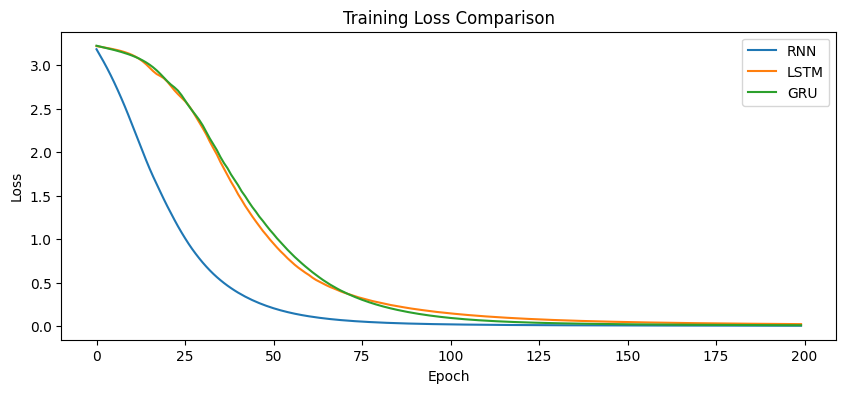

In [47]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history6.history['loss'], label='RNN')
plt.plot(lstm_history6.history['loss'], label='LSTM')
plt.plot(gru_history6.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

## ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [48]:
def generate_text6(model6, seed_text6, next_words6=5):
    for _ in range(next_words6):
        token_list6 = tokenizer6.texts_to_sequences([seed_text6])[0]
        token_list6 = pad_sequences([token_list6], maxlen=max_len-1, padding='pre')
        predicted6 = np.argmax(model6.predict(token_list6, verbose=0), axis=-1)[0]

        output_word6 = ""
        for word6, index6 in tokenizer6.word_index.items():
            if index6 == predicted6:
                output_word6 = word6
                break
        seed_text6 += " " + output_word6
    return seed_text6

## 🧪 Generate Text Samples

In [49]:
print("RNN :", generate_text6(rnn_model6, "machine learning", 10))
print("LSTM:", generate_text6(lstm_model6, "machine learning", 10))
print("GRU :", generate_text6(gru_model6, "machine learning", 10))

RNN : machine learning is a subset of artificial intelligence artificial performance multiple performance
LSTM: machine learning is a of artificial intelligence intelligence performance performance performance intelligence
GRU : machine learning is a subset of artificial intelligence intelligence intelligence intelligence intelligence


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**